In [68]:
import pandas as pd
import seaborn as sns

In [69]:
insurance_data = pd.read_csv("insurance.csv")
insurance_data.head()

insurance_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


<Axes: xlabel='bmi', ylabel='charges'>

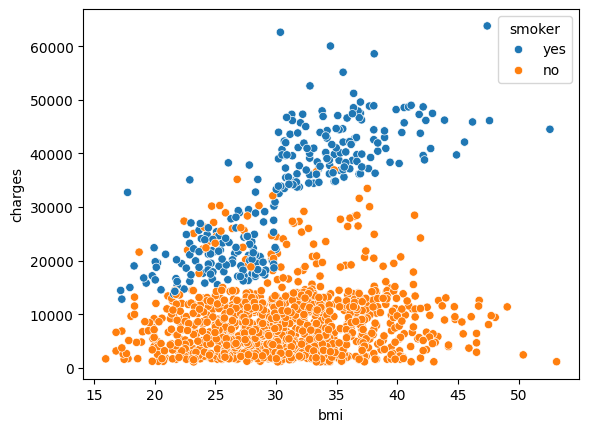

In [70]:
# visualization

sns.scatterplot(x=insurance_data["bmi"], y=insurance_data["charges"], hue=insurance_data["smoker"])


## Part 1 : training data (without region)

In [71]:
X = insurance_data.drop(columns=["charges" , "region"] )
y = insurance_data["charges"]

X["sex"] = X["sex"].map({
    "female":1,
    "male":0
})

X["smoker"] = X["smoker"].map({
    "yes":1,
    "no":0
})


### Train-Test split

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state=42
)


### Train model

In [73]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [74]:
#prediction for new testing data

y_pred = model.predict(X_test)

In [75]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print ("r-squared : ", r2)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))
print("adjusted_r-squared : ", adjusted_r2)


r-squared :  0.7811302113434095
adjusted_r-squared :  0.7769533069797342


## Part 2 : training data with different columns

In [76]:
X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

X["smoker"] = X["smoker"].map({
    "yes":1,
    "no":0
})
X["sex"] = X["sex"].map({
    "female":1,
    "male":0
})


#one hot encoding
X = pd.get_dummies(X, columns=["region"] , drop_first=True , dtype=int)

X.head()


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,0,0,1
1,18,0,33.770,1,0,0,1,0
2,28,0,33.000,3,0,0,1,0
3,33,0,22.705,0,0,1,0,0
4,32,0,28.880,0,0,1,0,0


In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state=42
)

model = LinearRegression()


model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print ("r-squared : ", r2)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))
print("adjusted_r-squared : ", adjusted_r2)

r-squared :  0.7835929767120724
adjusted_r-squared :  0.7769085898923681


## Part 3 : Interaction feature

In [78]:
X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

X["smoker"] = X["smoker"].map({
    "yes":1,
    "no":0
})
X["sex"] = X["sex"].map({
    "female":1,
    "male":0
})

X = pd.get_dummies(X, columns=["region"] , drop_first=True , dtype=int)

#interaction feature
X["age_smoker"] = X["age"] * X["smoker"]

X["bmi_smoker"] = X["bmi"] * X["smoker"]

X.head()




,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,1,19,27.9
1,18,0,33.770,1,0,0,1,0,0,0.0
2,28,0,33.000,3,0,0,1,0,0,0.0
3,33,0,22.705,0,0,1,0,0,0,0.0
4,32,0,28.880,0,0,1,0,0,0,0.0


In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state=42
)

model = LinearRegression()


model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print ("r-squared : ", r2)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))
print("adjusted_r-squared : ", adjusted_r2)

r-squared :  0.865231697953168
adjusted_r-squared :  0.8599877951497893


### underfit  & overfit check

In [82]:
# r2 training is low       and r2 testing is also low  => underfit
# r2 training is high       and r2 testing is also low  => overfit

y_train_pred = model.predict(X_train)

r2_train = r2_score(y_train, y_train_pred)

y_test_pred = model.predict(X_test)

r2_test = r2_score(y_test, y_test_pred)

print("training data r2 score : " , r2_train)
print("testing data r2 score :" , r2_test)

training data r2 score :  0.8340713711218875
testing data r2 score : 0.865231697953168
